In [1]:
import pandas as pd

In [42]:
df = pd.read_csv(r"/mnt/c/Rig/Pandoras BOX/RAGnRoll/data/raw/spotify_data.csv")

In [43]:
df.head()

,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [4]:
df.columns

Index(['Unnamed: 0', 'artist_name', 'track_name', 'track_id', 'popularity',
       'year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature'],
      dtype='object')

In [5]:
print(df.duplicated().sum())
print(print(df.isnull().sum()))

0
Unnamed: 0           0
artist_name         15
track_name           1
track_id             0
popularity           0
year                 0
genre                0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
duration_ms          0
time_signature       0
dtype: int64
None


In [6]:
df = df.dropna()

In [7]:
df['year'].value_counts().sort_index()

year
2000    44034
2001    42351
2002    42102
2003    42368
2004    43390
2005    43779
2006    45474
2007    46001
2008    47432
2009    46869
2010    46868
2011    46444
2012    54797
2013    53216
2014    53179
2015    51607
2016    40273
2017    56238
2018    56565
2019    55788
2020    55066
2021    53566
2022    53692
2023    38649
Name: count, dtype: int64

In [8]:
print("Types of Music Genres =",df['genre'].nunique())
print(df['genre'].value_counts().sort_values())

Types of Music Genres = 82
genre
songwriter          589
rock               3319
detroit-techno     3920
dubstep            4774
chicago-house      5170
                  ...  
alt-rock          20918
acoustic          21097
ambient           21389
gospel            21621
black-metal       21837
Name: count, Length: 82, dtype: int64


In [48]:
df.nunique()

Unnamed: 0          1159764
artist_name           64158
track_name           882360
track_id            1159764
popularity               98
year                     24
genre                    82
danceability           1364
energy                 3116
key                      12
loudness              37368
mode                      2
speechiness            1655
acousticness           5398
instrumentalness       5402
liveness               1816
valence                2177
tempo                135697
duration_ms          258021
time_signature            5
dtype: int64

In [10]:
# drop the Index column "Unnamed:0"
df = df.drop(['Unnamed: 0'], axis=1)

In [11]:
df.sample()

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
1111606,Hansson de Wolfe United,Svalan,4z3Cy6U7DJ0s53vy3GgHqa,10,2010,swedish,0.748,0.585,7,-8.765,1,0.0316,0.262,0.000066,0.104,0.782,131.22,229756,4


In [12]:
df['genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'ambient', 'black-metal',
       'blues', 'breakbeat', 'cantopop', 'chicago-house', 'chill',
       'classical', 'club', 'comedy', 'country', 'dance', 'dancehall',
       'death-metal', 'deep-house', 'detroit-techno', 'disco',
       'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic',
       'emo', 'folk', 'forro', 'french', 'funk', 'garage', 'german',
       'gospel', 'goth', 'grindcore', 'groove', 'guitar', 'hard-rock',
       'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'house',
       'indian', 'indie-pop', 'industrial', 'jazz', 'k-pop', 'metal',
       'metalcore', 'minimal-techno', 'new-age', 'opera', 'party',
       'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house',
       'psych-rock', 'punk', 'punk-rock', 'rock', 'rock-n-roll',
       'romance', 'sad', 'salsa', 'samba', 'sertanejo', 'show-tunes',
       'singer-songwriter', 'ska', 'sleep', 'songwriter', 'soul',
       'spanish', 'swedish', 'tango', 'tec

<Axes: xlabel='year'>

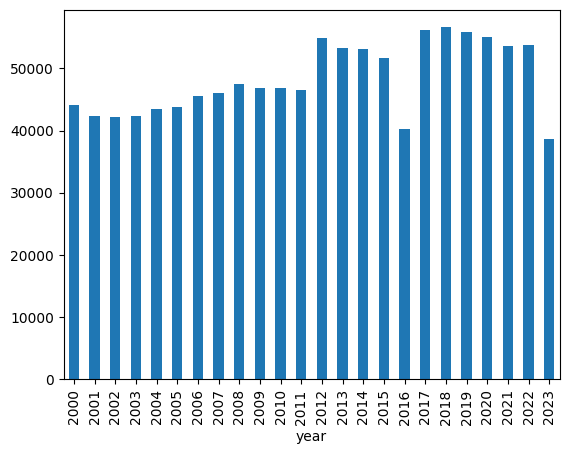

In [13]:
df["year"].value_counts().sort_index().plot(kind = 'bar')

In [14]:
dups = df['track_name'].str.lower()

In [15]:
dups.duplicated().sum()

np.int64(305306)

Oh my God. Is this dataset done for?

In [16]:
dups_track_artist = (
    df.assign(
        track_name_clean=df["track_name"].str.lower().str.strip(),
        artist_name_clean=df["artist_name"].str.lower().str.strip()
    )
    .duplicated(subset=["track_name_clean", "artist_name_clean"])
    .sum()
)

dups_track_artist

np.int64(7868)

In [17]:
dups_track_artist_duration = (
    df.assign(
        track_name_clean=df["track_name"].str.lower().str.strip(),
        artist_name_clean=df["artist_name"].str.lower().str.strip(),
        duration_rounded=(df["duration_ms"] / 1000).round()
    )
    .duplicated(subset=["track_name_clean", "artist_name_clean", "duration_rounded"])
    .sum()
)

dups_track_artist_duration

np.int64(2928)

In [18]:
dups_track_artist_genre = (
    df.assign(
        track_name_clean=df["track_name"].str.lower().str.strip(),
        artist_name_clean=df["artist_name"].str.lower().str.strip(),
        genre=df["genre"].str.lower().str.strip()
    )
    .duplicated(subset=["track_name_clean", "artist_name_clean", "genre"])
    .sum()
)

dups_track_artist_duration

np.int64(2928)

In [19]:
name_counts = (
    df["track_name"]
    .str.lower()
    .str.strip()
    .value_counts()
    .head(20)
)

name_counts

track_name
intro          484
home           323
forever        240
stay           230
hold on        229
lost           208
you            202
breathe        201
without you    197
tonight        193
heaven         192
alone          185
time           181
closer         166
crazy          161
paradise       160
dreams         159
shine          159
alive          158
ghost          156
Name: count, dtype: int64

In [20]:
'''Thank Heavens
Duplicates dups_track_artist shows lesser amount of 'duplications'

dups_track_artist_duration shows the actual duplicated rows: 2928

name_counts shows the common catalogue names that r repeated'''

"Thank Heavens\nDuplicates dups_track_artist shows lesser amount of 'duplications'\n\ndups_track_artist_duration shows the actual duplicated rows: 2928\n\nname_counts shows the common catalogue names that r repeated"

In [21]:
import re

def normalize_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

df_clean = df.copy()

df_clean["track_name_clean"] = df_clean["track_name"].apply(normalize_text)
df_clean["artist_name_clean"] = df_clean["artist_name"].apply(normalize_text)

df_clean["duration_seconds_rounded"] = (
    df_clean["duration_ms"] / 1000
).round().astype(int)

dedupe_cols = [
    "track_name_clean",
    "artist_name_clean",
    "duration_seconds_rounded"
]

df_clean = df_clean.sort_values(
    by=["popularity"],
    ascending=False
)

df_deduped = (
    df_clean
    .drop_duplicates(subset=dedupe_cols, keep="first")
    .reset_index(drop=True)
)

print("Original shape:", df.shape)
print("Deduped shape:", df_deduped.shape)
print("Rows removed:", len(df) - len(df_deduped))
print("Removed %:", round((len(df) - len(df_deduped)) / len(df) * 100, 2))

Original shape: (1159748, 19)
Deduped shape: (1156820, 22)
Rows removed: 2928
Removed %: 0.25


In [22]:
df_deduped.columns

Index(['artist_name', 'track_name', 'track_id', 'popularity', 'year', 'genre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature', 'track_name_clean',
       'artist_name_clean', 'duration_seconds_rounded'],
      dtype='object')

In [23]:
'''I dropped key, mode, and time_signature because they are more relevant for advanced music-theory or DJ-style sequencing than for V1 mood retrieval. mode overlaps with valence, key matters more for harmonic mixing, and time_signature has low practical signal for typical playlist prompts'''

'I dropped key, mode, and time_signature because they are more relevant for advanced music-theory or DJ-style sequencing than for V1 mood retrieval. mode overlaps with valence, key matters more for harmonic mixing, and time_signature has low practical signal for typical playlist prompts'

In [24]:
df_clean = df_deduped.drop([
        'track_name_clean','artist_name_clean','duration_seconds_rounded',
        'mode', 'key', 'time_signature'
        ], axis = 1)

In [25]:
df_clean.shape

(1156820, 16)

In [26]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,1156820.0,18.410642,15.885739,0.0,5.000000,15.00000,29.000,100.000
year,1156820.0,2011.955684,6.804237,2000.0,2006.000000,2012.00000,2018.000,2023.000
danceability,1156820.0,0.537381,0.184470,0.0,0.413000,0.55000,0.677,0.993
energy,1156820.0,0.639589,0.270517,0.0,0.453000,0.69400,0.873,1.000
loudness,1156820.0,-8.983674,5.684086,-58.1,-10.832000,-7.45100,-5.277,6.172
speechiness,1156820.0,0.092825,0.126888,0.0,0.037100,0.05070,0.089,0.971
acousticness,1156820.0,0.321589,0.354994,0.0,0.006410,0.14700,0.640,0.996
instrumentalness,1156820.0,0.252373,0.365103,0.0,0.000001,0.00176,0.614,1.000
liveness,1156820.0,0.223055,0.201114,0.0,0.097900,0.13400,0.292,1.000
valence,1156820.0,0.455466,0.268505,0.0,0.226000,0.43800,0.674,1.000


In [27]:
(df_clean["loudness"] > 0).sum()

np.int64(1191)

In [28]:
df_clean[df_clean["loudness"] > 0][
    ["track_name", "artist_name", "genre", "popularity", "duration_ms", "loudness", "energy"]
].sort_values("popularity", ascending=False).head(20)

,track_name,artist_name,genre,popularity,duration_ms,loudness,energy
173,Puta Mexicana,DJ Jeeh FDC,funk,83,162461,0.963,0.913
1550,Se Voce Nao Quer Passa a Vez,Mc Delux,funk,74,133846,1.295,0.827
5690,Eu Já Sofri por Amor Mas Não Sofro Mais (Tik Tok),MC Teuzin PV,funk,66,134737,0.832,0.855
6941,Baile do Cinga do 12,MC Gontijo,funk,65,181882,1.034,0.568
7709,Welcome to the Party (with French Montana & Li...,Diplo,dance,64,181720,0.175,0.845
8661,Voltei pra Cachorrada,DJ Jeeh FDC,funk,64,206811,1.420,0.748
13820,Swag Like Ohio,Lil B,hip-hop,61,174323,0.792,0.942
14335,Nao é tik tok,DJ Ws da Igrejinha,funk,60,132923,2.187,0.737
14358,"O Que Adianta Bê, Ser Tão Gostosa Se Ela É da ...",PL JUNIOR,funk,60,121544,0.070,0.897
17472,Aftershock,Macky Gee,house,59,230400,0.444,0.922


In [29]:
print("No. of songs longer than '35' minutes :",(df_clean["duration_ms"] > 2100000).sum())
print("No. of songs shorter than '55' seconds :",(df_clean["duration_ms"] < 55000).sum())

No. of songs longer than '35' minutes : 827
No. of songs shorter than '55' seconds : 10386


In [30]:
df_clean[df_clean["duration_ms"] > 2100000][
    ["track_name", "artist_name", "genre", "popularity", "duration_ms", "loudness", "energy"]
].sort_values("popularity", ascending=False).head(20)

,track_name,artist_name,genre,popularity,duration_ms,loudness,energy
31683,Om Bhurbhuwasah,Anuradha Paudwal,k-pop,54,3340672,-9.153,0.466000
47304,Ocean Waves for Sleep,Ocean Waves For Sleep,sleep,51,4120258,-17.379,0.995000
62363,1 Hour Rain and Thunder,Sleep Fruits Music,sleep,48,3603000,-24.400,1.000000
92660,Gayatri Mantra108 Jaap,Suresh Wadkar,k-pop,44,2342792,-13.117,0.415000
94984,1 Hour Deep Sleep Music,Sleep Fruits Music,sleep,43,3608000,-35.725,0.010000
98196,Siva Simiran / Siva Amrithavani / Shambho Tere...,Anuradha Paudwal,k-pop,43,3639107,-6.008,0.671000
99285,Internal Flight (Remastered),Estas Tonne,guitar,43,3876277,-9.266,0.640000
132203,Dopesmoker - 2022 Remastered Version,Sleep,metal,40,3809027,-13.268,0.419000
139734,Shiv Amritwani,Anuradha Paudwal,pop-film,39,2954509,-6.342,0.656000
145467,Ocean Waves Sounds,Ocean Sounds,sleep,38,4120258,-17.379,0.995000


In [31]:
df_clean[df_clean["duration_ms"] < 55000][
    ["track_name", "artist_name", "genre", "popularity", "duration_ms", "loudness", "energy"]
].sort_values("popularity", ascending=False).head(20)

,track_name,artist_name,genre,popularity,duration_ms,loudness,energy
1923,We Might Even Be Falling In Love (Interlude),Victoria Monét,chill,73,51914,-8.913,0.506
5401,Interlude,Kelsea Ballerini,country,67,45787,-8.132,0.615
7220,"Rain and Thunderstorm, Pt. 1",Rain Fruits Sounds,sleep,65,43000,-23.953,0.990
7342,Choice,Jack Stauber's Micropop,indie-pop,65,39591,-7.278,0.647
10266,"Rain and Thunderstorm, Pt. 2",Rain Fruits Sounds,sleep,63,42000,-24.407,0.997
10314,"Rain and Thunderstorm, Pt. 4",Rain Fruits Sounds,sleep,63,40000,-25.603,1.000
10316,"Rain and Thunderstorm, Pt. 3",Rain Fruits Sounds,sleep,63,41000,-25.277,1.000
10318,"Rain and Thunderstorm, Pt. 5",Rain Fruits Sounds,sleep,63,39000,-23.062,0.988
10319,"Rain and Thunderstorm, Pt. 34",Rain Fruits Sounds,sleep,63,38000,-23.990,0.807
10324,"Rain and Thunderstorm, Pt. 7",Rain Fruits Sounds,sleep,63,37000,-25.071,1.000


In [32]:
'''
From observation, found some real music (NFAK, Piano Concerto No.1, Pink Floyd, Gayatri Mantra) more than 20 min
Cant just remove these classics. Will be keeping them. Also 'sleep' genre music is long in nature, cant remove it on advice of AI
But I would like to remove songs over 35 min. Doesnt really help our cause. Ig listen to smaller versions Mate

And yea. Remove these songs less than 55 seconds.
'''

"\nFrom observation, found some real music (NFAK, Piano Concerto No.1, Pink Floyd, Gayatri Mantra) more than 20 min\nCant just remove these classics. Will be keeping them. Also 'sleep' genre music is long in nature, cant remove it on advice of AI\nBut I would like to remove songs over 35 min. Doesnt really help our cause. Ig listen to smaller versions Mate\n\nAnd yea. Remove these songs less than 55 seconds.\n"

In [33]:
# NOTE: Bhakti geet are coming under k-pop. Correct this.

In [34]:
# Remove invalid loudness and unsuitable durations
before = len(df_clean)

df_final = df_clean[
    (df_clean["loudness"] <= 0) &
    (df_clean["duration_ms"] >= 55_000) &
    (df_clean["duration_ms"] <= 2100000)   # 30 minutes
].copy()

after = len(df_final)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)
print("Removed %:", round((before - after) / before * 100, 2))

Rows before: 1156820
Rows after: 1144452
Rows removed: 12368
Removed %: 1.07


In [35]:
df_clean[df_clean["genre"] == 'k-pop'][
    ["track_name", "artist_name", "genre", "popularity", "duration_ms", "loudness", "energy"]
].sort_values("popularity", ascending=False).tail(40)

,track_name,artist_name,genre,popularity,duration_ms,loudness,energy
1132834,Soon And Very Soon - 99 Remix,Brenda Fassie,k-pop,0,275960,-8.321,0.692
1132835,Too Late For Mama,Brenda Fassie,k-pop,0,353440,-3.813,0.830
1132836,Andha Naal Nyabagam (Chill Trap),T. M. Soundararajan,k-pop,0,127024,-17.479,0.407
1132837,Ponaal Pogattum - Remix,T. M. Soundararajan,k-pop,0,184000,-2.689,0.950
1132838,Kannai Nambaadhe (Lofi),T. M. Soundararajan,k-pop,0,118306,-20.059,0.267
1132839,Yaarai Nambi Naan Poranthen (Remix),T. M. Soundararajan,k-pop,0,122643,-2.045,0.953
1132840,Chico malo,MAMAMOO,k-pop,0,159067,-2.467,0.769
1132841,Tum Nahin Aaye Abhi - Main Aur Meri Tanhai / S...,Jagjit Singh,k-pop,0,250547,-10.278,0.449
1132842,Teri Aankhon Se Hi - Dhoop / Soundtrack Version,Jagjit Singh,k-pop,0,356107,-10.304,0.444
1132843,Hothon Se Chhu Lo Tum - From Prem Geet,Jagjit Singh,k-pop,0,293347,-6.953,0.495


In [36]:
'''
Many of the trailing songs in k-pop are indian!!!!
Have to rectify this somehow.
'''

'\nMany of the trailing songs in k-pop are indian!!!!\nHave to rectify this somehow.\n'

In [37]:
df_final

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,Miley Cyrus,Flowers,0yLdNVWF3Srea0uzk55zFn,100,2023,pop,0.707,0.681,-4.325,0.0668,0.063200,0.000005,0.0322,0.646,117.999,200455
1,Bizarrap,"Shakira: Bzrp Music Sessions, Vol. 53",4nrPB8O7Y7wsOCJdgXkthe,96,2023,hip-hop,0.778,0.632,-5.600,0.0493,0.274000,0.000000,0.0915,0.498,122.104,218289
2,The Weeknd,Die For You - Remix,7oDd86yk8itslrA9HRP2ki,95,2023,pop,0.531,0.525,-6.500,0.0671,0.232000,0.000000,0.4410,0.502,66.900,232857
3,SZA,Kill Bill,1Qrg8KqiBpW07V7PNxwwwL,94,2022,pop,0.644,0.735,-5.747,0.0391,0.052100,0.144000,0.1610,0.418,88.980,153947
4,Rema,Calm Down (with Selena Gomez),0WtM2NBVQNNJLh6scP13H8,93,2022,pop,0.801,0.806,-5.206,0.0381,0.382000,0.000669,0.1140,0.802,106.999,239318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1156815,"Up, Bustle & Out",City Breakers - Dub,4l2TDE7zBZEia6Hwo68OGt,0,2011,trip-hop,0.744,0.648,-9.106,0.1510,0.014400,0.862000,0.6600,0.697,83.974,210227
1156816,Red Snapper,Loveboat,4FotzpAtiU1Gn45zDU7hZN,0,2011,trip-hop,0.518,0.925,-5.475,0.0408,0.000076,0.144000,0.1260,0.382,74.974,287318
1156817,The Orb,DDD - Dirty Disco Dub,43wRdzH4xNs8VzBDDzAsYl,0,2011,trip-hop,0.728,0.792,-9.247,0.0365,0.065700,0.165000,0.6630,0.628,100.605,302733
1156818,Belleruche,Fuzz Face - Pollyn Remix,0HdeYH0vK7QbE1AJDGQ78Y,0,2011,trip-hop,0.708,0.887,-7.764,0.0493,0.012200,0.181000,0.0710,0.592,95.463,290867


In [49]:
df_final.to_csv("cleaned_spotify_1M.csv", index=False)